Here, difference of this notebook is that we take HC as normative distribution, and calculate BP deviation from that 

In [48]:
import pandas as pd
df_all=pd.read_csv("/Users/kaankeskin/projects/FrequencySliding/data/output/int_perROI.csv",index_col=0)
print(df_all)

                       0         1         2         3         4         5  \
subject                                                                      
sub-1.results   3.475919  3.259526  2.244792  2.350386  3.381852  2.353142   
sub-10.results  2.266367  2.049568  2.102273  2.238936  2.095142  2.324839   
sub-11.results  2.297576  1.960341  2.151885  2.362398  2.228264  2.406481   
sub-12.results  2.230671  1.907239  2.266473  2.258538  2.299206  2.385814   
sub-13.results  3.583674  2.321462  3.405805  2.336265  2.269004  2.316978   
...                  ...       ...       ...       ...       ...       ...   
sub-71.results  3.593782  2.339195  2.273456  3.404723  3.482768  3.407946   
sub-72.results  2.330525  2.126229  1.974536  2.292778  2.193579  2.101340   
sub-73.results  2.171043  2.048678  2.237080  2.027276  2.141627  2.148189   
sub-74.results  2.181589  2.158492  2.130752  2.157047  1.907155  1.975759   
sub-75.results  1.941120  1.771465  1.942376  1.775015  2.088682

In [49]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- Paths ---
ctrl_path = Path(r"/Users/kaankeskin/projects/FrequencySliding/data/raw")
ctrl_csv = ctrl_path / "controlregions.csv"

# --- Read CSV ---
# We'll not assume headers; we'll read and rename first two cols defensively.
ctrl_df = pd.read_csv(ctrl_csv)

# If the file has no header row and just two columns, uncomment:
# ctrl_df = pd.read_csv(ctrl_csv, header=None, names=["transmodal", "unimodal"])

# Ensure we have at least two columns
if ctrl_df.shape[1] < 2:
    raise ValueError("controlregions.csv must have at least two columns (transmodal, unimodal).")

# Normalize column names (optional but convenient)
ctrl_df = ctrl_df.rename(columns=lambda c: str(c).strip().lower())

# Try to find columns by name; fall back to positional
trans_col = next((c for c in ctrl_df.columns if "trans" in c), ctrl_df.columns[0])
uni_col   = next((c for c in ctrl_df.columns if "uni" in c),   ctrl_df.columns[1])

transmask_raw = ctrl_df[trans_col].to_numpy()
unimask_raw   = ctrl_df[uni_col].to_numpy()

# --- Coerce to boolean masks ---
# Treat nonzero & non-null as True
transmask = np.asarray(transmask_raw, dtype=float)
unimask   = np.asarray(unimask_raw, dtype=float)

# If any NaNs, treat as 0
transmask = np.nan_to_num(transmask, nan=0.0)
unimask   = np.nan_to_num(unimask,   nan=0.0)

transmask_bool = transmask.astype(bool)
unimask_bool   = unimask.astype(bool)

# --- Check mask lengths vs df_all columns ---
n_roi_mask = len(transmask_bool)
n_roi_df   = df_all.shape[1]

if n_roi_mask != n_roi_df:
    raise ValueError(
        f"Mask length ({n_roi_mask}) != number of ROI columns in df_all ({n_roi_df}). "
        "We need a mapping or confirmation of ROI order."
    )

# --- Compute subject means across masked ROIs ---
# df_all: subjects × ROIs
MF_transmodal = df_all.loc[:, transmask_bool].mean(axis=1, skipna=True)
MF_unimodal   = df_all.loc[:, unimask_bool].mean(axis=1, skipna=True)

# --- Append to df_all ---
df_all = df_all.copy()
df_all["MF_transmodal"] = MF_transmodal
df_all["MF_unimodal"]   = MF_unimodal
print(df_all)


                       0         1         2         3         4         5  \
subject                                                                      
sub-1.results   3.475919  3.259526  2.244792  2.350386  3.381852  2.353142   
sub-10.results  2.266367  2.049568  2.102273  2.238936  2.095142  2.324839   
sub-11.results  2.297576  1.960341  2.151885  2.362398  2.228264  2.406481   
sub-12.results  2.230671  1.907239  2.266473  2.258538  2.299206  2.385814   
sub-13.results  3.583674  2.321462  3.405805  2.336265  2.269004  2.316978   
...                  ...       ...       ...       ...       ...       ...   
sub-71.results  3.593782  2.339195  2.273456  3.404723  3.482768  3.407946   
sub-72.results  2.330525  2.126229  1.974536  2.292778  2.193579  2.101340   
sub-73.results  2.171043  2.048678  2.237080  2.027276  2.141627  2.148189   
sub-74.results  2.181589  2.158492  2.130752  2.157047  1.907155  1.975759   
sub-75.results  1.941120  1.771465  1.942376  1.775015  2.088682

In [50]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# 1. Load BP sheet (Excel): has SubjectID, Total Score, Age, Sex
# ------------------------------------------------------------------
bp_subj = pd.read_excel(
    r"/Users/kaankeskin/projects/FrequencySliding/data/raw/BDI_ThreeFactor_MultiSubject.xlsx"
)

# Standardize column names just in case
bp_subj = bp_subj.rename(columns=lambda c: str(c).strip())

# Rename Total Score -> BDI; keep needed columns
bp_use = (
    bp_subj.rename(columns={"Total Score": "BDI"})[["SubjectID", "BDI", "Age", "Sex"]]
    .assign(Group="BP")
)

# ------------------------------------------------------------------
# 2. Load HC participants slice from TSV and drop exclusions
# ------------------------------------------------------------------
df = pd.read_csv(r"/Volumes/HD-B1/BIDS/participants.tsv", sep="\t")

# R slice(35:70) => pandas iloc[34:70] (sub-35..sub-70 inclusive in R)
df_slice = df.iloc[34:70].copy()

exclude_ids = ["sub-54", "sub-39", "sub-58"]
hc_subj = df_slice.loc[~df_slice["participant_id"].isin(exclude_ids)].copy()

# Number of HC subjects kept
n = len(hc_subj)

# ------------------------------------------------------------------
# 3. Build renumbered HC ID list starting at 43
# ------------------------------------------------------------------
start_id = 43
hc_ids_renum = [f"sub-{start_id + i}" for i in range(n)]

# Create HC BDI/demographics DataFrame with renumbered IDs
hc_bdi_renum_df = pd.DataFrame({
    "SubjectID": hc_ids_renum,
    "BDI": pd.to_numeric(hc_subj["BDI"], errors="coerce"),
    "Age": pd.to_numeric(hc_subj["Age"], errors="coerce"),
    "Sex": pd.to_numeric(hc_subj["Sex"], errors="coerce"),
    "Group": "HC",   # one value broadcast to all rows
})

# ------------------------------------------------------------------
# 4. Combine BP + HC into one BDI/demographics table
# ------------------------------------------------------------------
bdi_df = pd.concat([bp_use, hc_bdi_renum_df], axis=0, ignore_index=True)

# Ensure BDI numeric
bdi_df["BDI"] = pd.to_numeric(bdi_df["BDI"], errors="coerce")

# ------------------------------------------------------------------
# 5. Prepare df_all imaging data
#     (Assumes df_all already exists & MF_transmodal / MF_unimodal arrays ready)
# ------------------------------------------------------------------
df_all = df_all.copy()

# Add MF columns if not already present
df_all["MF_transmodal"] = MF_transmodal
df_all["MF_unimodal"]   = MF_unimodal

# Add clean SubjectID (strip ".results")
df_all["SubjectID"] = df_all.index.to_series().str.replace(".results", "", regex=False)

# ------------------------------------------------------------------
# 6. Merge BDI + Age + Sex into df_all by SubjectID
# ------------------------------------------------------------------
df_all = df_all.merge(
    bdi_df,                # has SubjectID, BDI, Age, Sex
    on="SubjectID",
    how="left",
    validate="m:1"         # one demographic row per SubjectID expected
)

# ------------------------------------------------------------------
# 7. Final metrics table with Age & Sex at the end
# ------------------------------------------------------------------
df_metrics = df_all.loc[:, ["SubjectID", "Group","BDI", "MF_transmodal", "MF_unimodal", "Age", "Sex"]].reset_index(drop=True)

print(df_metrics.head())
print(df_metrics.tail())
print("Shape:", df_metrics.shape)
print("Missing BDI:", df_metrics["BDI"].isna().sum())


  SubjectID Group   BDI  MF_transmodal  MF_unimodal   Age  Sex
0     sub-1    BP   8.0       2.469273     2.445759  56.0  2.0
1    sub-10    BP  30.0       2.312819     2.231091  26.0  2.0
2    sub-11    BP  44.0       2.462182     2.265152  54.0  1.0
3    sub-12    BP  38.0       2.354563     2.119424  40.0  1.0
4    sub-13    BP  22.0       2.996524     2.576615  52.0  2.0
   SubjectID Group  BDI  MF_transmodal  MF_unimodal   Age  Sex
67    sub-71    HC  2.0       2.168868     2.405853  22.0  2.0
68    sub-72    HC  3.0       2.232813     2.191192  31.0  1.0
69    sub-73    HC  0.0       2.230174     2.139176  28.0  1.0
70    sub-74    HC  8.0       2.284656     2.137331  46.0  2.0
71    sub-75    HC  1.0       2.049081     1.957002  20.0  2.0
Shape: (72, 7)
Missing BDI: 1


Removing some subjects because of head movement

In [51]:
drop_index=["sub-20", "sub-30","sub-35","sub-36","sub-37","sub-41","sub-42"]
df_metrics = df_metrics[~df_metrics["SubjectID"].isin(drop_index)]

print(df_metrics.head())
print(df_metrics.tail())
print("Shape:", df_metrics.shape)
print("Missing BDI:", df_metrics["BDI"].isna().sum())


  SubjectID Group   BDI  MF_transmodal  MF_unimodal   Age  Sex
0     sub-1    BP   8.0       2.469273     2.445759  56.0  2.0
1    sub-10    BP  30.0       2.312819     2.231091  26.0  2.0
2    sub-11    BP  44.0       2.462182     2.265152  54.0  1.0
3    sub-12    BP  38.0       2.354563     2.119424  40.0  1.0
4    sub-13    BP  22.0       2.996524     2.576615  52.0  2.0
   SubjectID Group  BDI  MF_transmodal  MF_unimodal   Age  Sex
67    sub-71    HC  2.0       2.168868     2.405853  22.0  2.0
68    sub-72    HC  3.0       2.232813     2.191192  31.0  1.0
69    sub-73    HC  0.0       2.230174     2.139176  28.0  1.0
70    sub-74    HC  8.0       2.284656     2.137331  46.0  2.0
71    sub-75    HC  1.0       2.049081     1.957002  20.0  2.0
Shape: (65, 7)
Missing BDI: 1


In [55]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

df2 = df_metrics.copy()
# Encode Sex to 0/1 if needed (your data are 1/2); choose a reference you prefer.
df2["Sex_bin"] = (df2["Sex"]==2).astype(int)

hc = df2[df2["Group"]=="HC"].copy()
bp = df2[df2["Group"]=="BP"].copy()

for col in ["MF_unimodal","MF_transmodal"]:
    X_hc = sm.add_constant(hc[["Age","Sex_bin"]])
    y_hc = hc[col]
    m = sm.OLS(y_hc, X_hc).fit()

    # Predict expected MF for BP under the HC model
    X_bp = sm.add_constant(bp[["Age","Sex_bin"]], has_constant="add")
    yhat_bp = m.predict(X_bp)

    # Use HC residual SD as normative SD
    resid_sd_hc = m.resid.std(ddof=int(m.df_model)+1)

    bp[f"{col}_adj_zHC"] = (bp[col] - yhat_bp) / resid_sd_hc

bp_adj_subject_devs = bp[["SubjectID","Group","MF_unimodal_adj_zHC","MF_transmodal_adj_zHC"]]
bp_adj_summary = bp[["MF_unimodal_adj_zHC","MF_transmodal_adj_zHC"]].agg(["mean","std","median"])

bp_adj_subject_devs = (
    df2.query("Group == 'BP'")[["SubjectID","Group","BDI","Age","Sex"]]
    .merge(
        bp[["SubjectID","MF_unimodal_adj_zHC","MF_transmodal_adj_zHC"]],
        on="SubjectID", how="left"
    )
    .sort_values("SubjectID")
    .reset_index(drop=True)
)

# Z transform for BDI
bp_adj_subject_devs = bp_adj_subject_devs.dropna(subset=["BDI"])

scaler = StandardScaler()
bp_adj_subject_devs[["z_BDI"]] = scaler.fit_transform(bp_adj_subject_devs[["BDI"]])  # the outcome
bp_adj_subject_devs[["z_Age"]] = scaler.fit_transform(bp_adj_subject_devs[["Age"]])  # the outcome
bp_adj_subject_devs["Sex"] = (bp_adj_subject_devs["Sex"]==2).astype(int)

print(bp_adj_subject_devs)

# Design Matrices
terms = ["z_Age", "Sex", "MF_transmodal_adj_zHC"]
X_mean = bp_adj_subject_devs[terms].to_numpy()                    # (N, P)
y = bp_adj_subject_devs["z_BDI"].to_numpy()                       # (N,)

groups = ["BP"]
X_grp = (pd.get_dummies(bp_adj_subject_devs["Group"])
           .reindex(columns=groups, fill_value=0)
           .to_numpy())                           # (N, G)

N, P = X_mean.shape
Gs = len(groups)

coords = {
    "obs": np.arange(N),
    "term": terms,
    "group": groups,
}



   SubjectID Group   BDI   Age  Sex  MF_unimodal_adj_zHC  \
0      sub-1    BP   8.0  56.0    1            -0.061902   
1     sub-10    BP  30.0  26.0    1            -0.516458   
2     sub-11    BP  44.0  54.0    0            -0.308302   
3     sub-12    BP  38.0  40.0    0            -0.677669   
4     sub-13    BP  22.0  52.0    1             0.428028   
5     sub-15    BP  10.0  23.0    1             1.231587   
6     sub-16    BP  25.0  31.0    0             0.832378   
7     sub-17    BP  52.0  19.0    1             1.327103   
8     sub-18    BP  25.0  30.0    0             1.166987   
9     sub-19    BP  18.0  30.0    1            -0.429942   
10     sub-2    BP  48.0  36.0    1            -0.710598   
11    sub-21    BP   3.0  39.0    1             0.948306   
12    sub-22    BP  19.0  55.0    1             0.849366   
13    sub-23    BP  32.0  42.0    1            -0.115614   
14    sub-24    BP  33.0  24.0    0             0.466591   
15    sub-25    BP  27.0  21.0    0     

In [56]:
import pymc as pm
import pytensor.tensor as pt
import numpy as np

with pm.Model(coords=coords) as model_grp1:

    # Mean
    Intercept = pm.Normal("Intercept", mu=0.0, sigma=0.5)
    b = pm.Normal("b", mu=0.0, sigma=0.30, dims="term")        # mean slopes
    mu = Intercept + pt.dot(X_mean, b)

    # sigma (log-link) per group
    b_sigma = pm.Normal("b_sigma", mu=0.0, sigma=0.25, dims="group")
    log_sigma = pt.dot(X_grp, b_sigma)
    sigma = pm.Deterministic("sigma", pt.exp(log_sigma), dims="obs")

    # nu (log-link) per group
    b_nu = pm.Normal("b_nu", mu=np.log(10.0), sigma=0.50, dims="group")
    log_nu = pt.dot(X_grp, b_nu)
    nu = pm.Deterministic("nu", pt.exp(log_nu), dims="obs")

    # Likelihood (Student-t for robustness)
    pm.StudentT("BDI_z", mu=mu, sigma=sigma, nu=nu, observed=y, dims="obs")

    idata_grp1 = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.9, random_seed=123,
        nuts_sampler="numpyro",
        mp_ctx="spawn",
    )


  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

In [57]:
import arviz as az

# --- Summaries ---------------------------------------------------------------
print(az.summary(idata_grp1, var_names=["Intercept","b"], hdi_prob=0.95))
print(az.summary(idata_grp1, var_names=["b_sigma","b_nu"], hdi_prob=0.95))

                           mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  \
Intercept                 0.012  0.232    -0.422      0.485      0.003   
b[z_Age]                 -0.257  0.162    -0.583      0.050      0.002   
b[Sex]                    0.084  0.229    -0.346      0.542      0.003   
b[MF_transmodal_adj_zHC] -0.200  0.197    -0.605      0.175      0.002   

                          mcse_sd  ess_bulk  ess_tail  r_hat  
Intercept                   0.002    6435.0    6712.0    1.0  
b[z_Age]                    0.002    8912.0    5639.0    1.0  
b[Sex]                      0.002    6572.0    6353.0    1.0  
b[MF_transmodal_adj_zHC]    0.002    9014.0    5617.0    1.0  
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
b_sigma[BP] -0.071  0.129    -0.324      0.182      0.001    0.001    8254.0   
b_nu[BP]     2.427  0.475     1.523      3.371      0.005    0.006   10100.0   

             ess_tail  r_hat  
b_sigma[BP]    5632.0    1.0  
b_nu[BP]   

Sampling: [BDI_z]


Output()

<Axes: xlabel='BDI_z'>

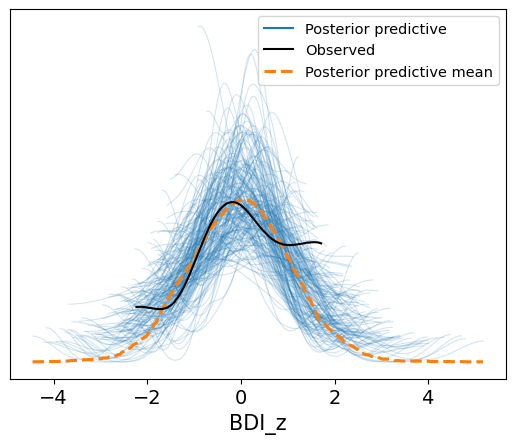

In [35]:
# Plot posterior predictive density 
import pymc as pm
import arviz as az
import numpy as np

# idata_grp1 was returned by pm.sample(...)
with model_grp1:
    # Draw posterior predictive samples for the observed node
    idata_grp1 = pm.sample_posterior_predictive(
        idata_grp1,                 # pass the fit
        var_names=["BDI_z"],        # the observed RV name
        random_seed=123,
        extend_inferencedata=True,  # add to idata_grp1.posterior_predictive
    )

# Quick PPC plot (overlayed densities / ECDFs)
az.plot_ppc(
    idata_grp1,
    data_pairs={"BDI_z": "BDI_z"},  # map obs name -> ppd name
    num_pp_samples=200,             # fewer curves for readability
)

/var/folders/mx/j9rl9nns0g7bz9pd9t16prh00000gn/T/ipykernel_7120/2576604094.py:23: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(y_pred, hdi_prob=0.95)  # 95% credible band


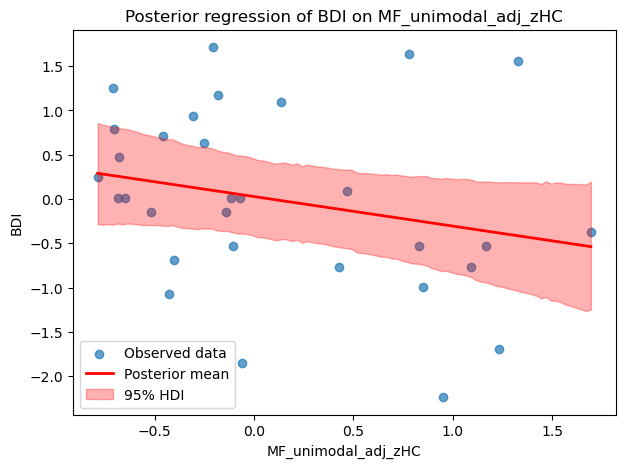

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

# Extract posterior draws for intercept and the slope of interest
posterior = idata_grp1.posterior

intercept_draws = posterior["Intercept"].stack(sample=("chain","draw")).values
slope_draws = posterior["b"].sel(term="MF_unimodal_adj_zHC").stack(sample=("chain","draw")).values

# Observed predictor and outcome
x_obs = bp_adj_subject_devs["MF_unimodal_adj_zHC"].values
y_obs = bp_adj_subject_devs["z_BDI"].values

# Define a grid of x for prediction
x_grid = np.linspace(x_obs.min(), x_obs.max(), 100)

# For each posterior sample, compute regression line
y_pred = intercept_draws[:, None] + slope_draws[:, None] * x_grid[None, :]

# Summarize posterior predictions
y_mean = y_pred.mean(axis=0)
hdi = az.hdi(y_pred, hdi_prob=0.95)  # 95% credible band

# ---- Plot ----
plt.figure(figsize=(7,5))
plt.scatter(x_obs, y_obs, alpha=0.7, label="Observed data")

plt.plot(x_grid, y_mean, color="red", lw=2, label="Posterior mean")
plt.fill_between(x_grid, hdi[:,0], hdi[:,1], color="red", alpha=0.3, label="95% HDI")

plt.xlabel("MF_unimodal_adj_zHC")
plt.ylabel("BDI")
plt.title("Posterior regression of BDI on MF_unimodal_adj_zHC")
plt.legend()
plt.show()


In [37]:
import xarray as xr

# grab posterior draws for the coefficient
draws = idata_grp1.posterior["b"].sel(term="MF_unimodal_adj_zHC")

# flatten chain/draw to a 1D array
vals = draws.stack(sample=("chain","draw")).values

# probability that slope < 0
p_negative = (vals < 0).mean()
p_positive = (vals > 0).mean()

print(f"P(b < 0) = {p_negative:.3f}")
print(f"P(b > 0) = {p_positive:.3f}")

P(b < 0) = 0.956
P(b > 0) = 0.044


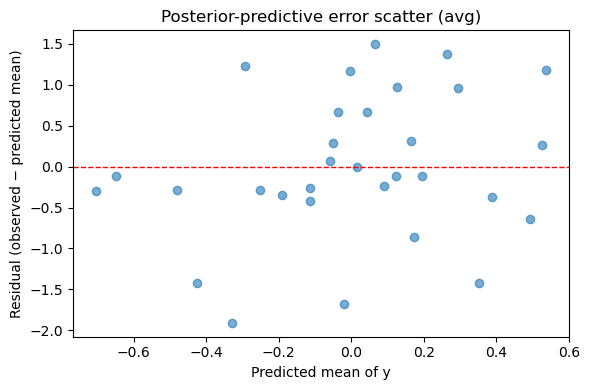

In [38]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# 3) Extract observed and predicted arrays
y_obs_arr   = idata_grp1.observed_data["BDI_z"].values
y_pred_arr  = idata_grp1.posterior_predictive["BDI_z"].values
#    shape of y_pred_arr is (chain, draw, obs_id)

# 4) Compute the posterior‐predictive mean for each observation
y_pred_mean = y_pred_arr.mean(axis=(0, 1))  # collapse chain & draw → (obs_id,)

# 5) Compute residuals
residuals = y_obs_arr - y_pred_mean

# 6) Plot “error_scatter_avg”
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_mean, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Predicted mean of y")
plt.ylabel("Residual (observed − predicted mean)")
plt.title("Posterior-predictive error scatter (avg)")
plt.tight_layout()
plt.show()